# 다변수 기반 암호 (MQ) 강의 노트북
## 다변수 이차식 기반 양자내성암호 (Multivariate Quadratic Cryptography)

---

이 노트북은 **수학 비전공자도 이해할 수 있도록** 다변수 기반(Multivariate) 양자내성암호를 쉽게 풀어 쓴 강의 자료입니다.
핵심 아이디어는 하나입니다. **"요리 레시피대로 요리를 만들기는 쉽지만, 완성된 요리만 보고
정확한 레시피를 역추적하기는 어렵다"** — 이런 일방통행 성질을 수식 대신 코드와 실측으로 확인합니다.

이론 설명 → 직접 구현 → 순방향/역방향 시간 실측 → 그래프 → 실무 적용성 판단 순서로 진행하며,
**"넣어서 계산하기는 순식간, 거꾸로 찾기는 사실상 불가능"이라는 비대칭성이 실제로 성립하는지** 눈으로 확인합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제(유형 ④ 다변수 기반)를
> 분리·정리한 강의 자료입니다. 실행 셀과 출력은 원본 그대로이며,
> 재실행하려면 **0장(Setup)의 공통 설정 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. MQ 문제(여러 변수가 얽힌 2차 방정식 여러 개를 동시에 푸는 문제)가 왜 어려운지 감을 잡는다.
2. "넣으면 답이 나오지만 거꾸로는 못 푸는" 일방향 함수를 파이썬 코드로 직접 만들어 본다.
3. 순방향(대입) 시간과 역방향(완전탐색) 비용을 실제로 재서 비교한다.
4. 변수 개수가 늘수록 두 비용의 격차가 폭발적으로 벌어지는 모습을 그래프로 관찰한다.
5. 다변수 계열 전자서명이 실무에서 어디에 쓰이고 어떤 장단점이 있는지 판단한다.

> **선행 지식**: 어려운 수학은 필요 없습니다. "나머지 구하기(mod)"가 무엇인지,
> 그리고 파이썬 코드를 대략 읽을 수 있으면 충분합니다. 수식이 나오면 바로 아래에 쉬운 풀이를 붙였습니다.


## 0. 준비 (Setup)

아래 셀은 통합본 전체가 공유하는 **공통 도구 상자(하니스, harness)** 입니다.
매번 같은 실험 결과가 나오도록 난수(무작위 수)의 시작점을 고정한 `RNG`,
그래프에서 한글이 깨지지 않게 하는 폰트 설정,
해시 헬퍼(`H`, `shake`), 크기 측정 `nbytes`, 시간 측정 `timeit`,
그리고 알고리즘별 측정값을 모아 두는 `METRICS` 저장소를 정의합니다.
이 노트북의 모든 코드 셀은 이 셀을 먼저 실행해야 동작합니다.


In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. 이론 — MQ 문제와 일방향성

### 1-1. 다변수 이차 연립방정식

먼저 비유부터 시작합니다. **요리 레시피가 있으면 요리를 만들기는 쉽습니다.
하지만 완성된 요리를 한 입 먹어 보고 "정확한 재료 배합과 조리 순서"를 역추적하기는 사실상 불가능합니다.**
다변수 기반 암호는 바로 이런 일방통행 성질을 수학 문제로 만든 것입니다.

여기서 레시피 역할을 하는 것이 $y = P(x)$ 라는 식입니다.

> **수식 풀이:** $x$ 는 우리가 넣는 재료(비밀 숫자들), $P$ 는 레시피(여러 개의 2차 방정식 묶음),
> $y$ 는 완성된 요리(계산 결과)입니다. $x$ 를 식에 넣어 $y$ 를 계산하는 건 순식간이지만,
> $y$ 만 보고 $x$ 를 거꾸로 찾는 건 사실상 불가능합니다.

이 노트북에서는 계산을 단순하게 하려고 GF(2), 즉 **0과 1 두 숫자만 쓰는 세계**(계산 결과를
항상 2로 나눈 나머지만 남기는 방식)에서 실험합니다. 변수 $n$ 개를 넣으면 답 $m$ 개가 나오는
2차 방정식 묶음을 만드는데, 여기서 두 방향의 난이도가 극단적으로 다릅니다.

- **순방향(대입)**: $x$ 를 알면 $y$ 는 곱셈·덧셈 몇 번으로 즉시 계산됩니다. 컴퓨터에게는 눈 깜짝할 일입니다.
- **역방향(역산)**: $y$ 만 보고 $x$ 를 되찾는 문제 — 이것이 **MQ 문제**(Multivariate Quadratic,
  여러 변수가 얽힌 2차 방정식 여러 개를 동시에 푸는 문제)입니다. 이 문제는
  **NP-난해**(컴퓨터 과학에서 "현존 컴퓨터로는 사실상 풀 수 없다"고 분류되는 어려움 등급)로 알려져 있습니다.

> **핵심**: 숫자를 식에 "넣어서 계산"하는 것은 순식간이지만, 결과만 보고 "원래 숫자를 거꾸로 찾는" 것은
> 사실상 불가능합니다. 이 **일방통행 도로 같은 비대칭성**이 다변수 기반 암호의 안전성 근거입니다.

중요한 점은, 이 어려움이 **양자 컴퓨터에게도 여전히 어렵다**는 것입니다.
RSA 같은 기존 암호(소인수분해 기반)는 양자 컴퓨터의 쇼어(Shor) 알고리즘이라는 지름길에 뚫리지만,
구조 없는 2차 방정식 묶음을 빠르게 푸는 양자 지름길은 알려져 있지 않습니다.
그래서 다변수 방식이 양자내성암호(PQC, 양자 컴퓨터 시대에도 안전하도록 설계된 차세대 암호)의 한 축이 됩니다.

### 1-2. 왜 서명에 쓰는가 — 부채널 저항성

이 일방통행 성질로 **도장(전자서명)** 을 만듭니다. 비밀 열쇠(트랩도어, 만든 사람만 아는 뒷문)를 가진
서명자만 역방향 계산을 해서 서명을 만들 수 있고, 검증하는 사람은 누구나 빠른 순방향 대입으로
"이 서명이 진짜인지" 확인할 수 있습니다.

다변수 계열의 실무적 강점은 계산이 **단순한 식 대입뿐**이라는 데 있습니다.
비밀값에 따라 계산 경로가 달라지거나 복잡한 연산을 섞지 않으므로,
**부채널 공격**(기기가 계산할 때 새어 나오는 전력 소모·전자파 같은 곁가지 신호를 훔쳐봐서
비밀을 알아내는 공격) — 특히 전기 사용 패턴을 분석하는 **전력분석** — 에 강합니다.
그래서 주 용도는 암호화가 아니라 **전자서명**입니다.

참고로, 한국 KpqC 공모(한국형 양자내성암호 표준을 뽑는 대회)에서 최종 선정된 서명 **AIMer** 도
넓게 보면 대칭 암호·일방향 함수 기반의 유사 계열로 분류할 수 있습니다.


## 2. 밑바닥 구현과 검증

**실험 설계**: "레시피대로 만들기는 쉽고, 역추적은 어렵다"를 코드로 직접 확인합니다.
0과 1만 쓰는 세계(GF(2))에서 변수 $n$ 개짜리 일방향 함수를 만들고,
**순방향 대입 시간**과 **역방향 완전탐색 비용($2^n$)** 을 직접 재서 비대칭성을 확인합니다.

> **수식 풀이:** $2^n$ 은 "2를 $n$ 번 곱한 수"입니다. 변수가 $n$ 개면 가능한 답 후보가
> $2^n$ 가지라서, 거꾸로 풀려면 최악의 경우 이만큼을 전부 시도해야 한다는 뜻입니다.

아래 셀은 세 함수를 정의하고 실험을 수행합니다.

- `mq_system(n, m, rng)`: 무작위 레시피(2차 방정식 묶음의 계수들)를 생성합니다.
- `mq_eval(Qs, x)`: 순방향 대입 — 재료 $x$ 를 레시피에 넣어 결과 $y$ 를 계산합니다.
- `mq_invert_brute(Qs, y, n)`: 역방향 — 비밀 열쇠 없이 **완전탐색**(가능한 후보 $2^n$ 개를
  처음부터 끝까지 하나씩 다 넣어 보는 무식하지만 확실한 방법)으로 $x$ 를 찾습니다.

$n = 8, 12, 16, 20$ 에 대해 순방향 시간(50회 평균)을 재고,
$n \le 16$ 에서만 실제 역산을 수행합니다($n = 20$ 은 $2^{20}$ 회 탐색이라 생략).


In [21]:
# ③ 밑바닥 구현 — 다변수 이차 일방향 함수 P: GF(2)^n -> GF(2)^n
def mq_system(n, m, rng):
    return [rng.integers(0, 2, (n, n)) for _ in range(m)]   # 각 식의 2차항 계수행렬
def mq_eval(Qs, x):
    return np.array([int(x @ (Q @ x) % 2) for Q in Qs])     # y_k = x^T Q_k x  (대입=빠름)
def mq_invert_brute(Qs, y, n):
    for v in range(2 ** n):                                 # 역방향 = 완전탐색(지수)
        x = np.array([(v >> i) & 1 for i in range(n)])
        if np.array_equal(mq_eval(Qs, x), y):
            return x, v + 1
    return None, 2 ** n

# ④ 검증 — 순방향 즉시 / 역방향 지수적
rows = []
for n in [8, 12, 16, 20]:
    Qs = mq_system(n, n, RNG)
    x = RNG.integers(0, 2, n)
    y = mq_eval(Qs, x)
    _, t_fwd = timeit(mq_eval, Qs, x, repeat=50)
    if n <= 16:
        (xr, tries), t_inv = timeit(mq_invert_brute, Qs, y, n)
        found = xr is not None
    else:
        tries, t_inv, found = 2 ** n, None, None
    rows.append({'n': n, 'forward_us': t_fwd*1e6, 'inverse_search_space': f'2^{n}={2**n:,}',
                 'inverted': found})
df_mq = pd.DataFrame(rows)
print(df_mq.to_string(index=False))
print('\n→ 순방향 대입은 마이크로초, 역방향은 2^n 완전탐색. 이 격차가 안전성.')
log_metric('Multivariate', forward='us', inverse='2^n', note='부채널 강함·서명용')

 n  forward_us inverse_search_space inverted
 8      48.914              2^8=256     True
12      77.360           2^12=4,096     True
16      81.542          2^16=65,536     True
20     102.916       2^20=1,048,576     None

→ 순방향 대입은 마이크로초, 역방향은 2^n 완전탐색. 이 격차가 안전성.


### 2-1. 결과 해석

출력 표를 보면 "만들기는 쉽고 역추적은 어렵다"는 비대칭성이 그대로 드러납니다.

- **순방향 대입 시간(`forward_us`)**: $n = 8$ 에서 약 48.9μs(마이크로초, 100만분의 1초),
  $n = 20$ 에서도 약 102.9μs. 변수가 8개에서 20개로 늘어도
  **눈 깜짝할 시간 안에서 완만하게** 증가할 뿐입니다.
- **역방향 탐색 공간(`inverse_search_space`)**: 같은 구간에서 $2^8 = 256$ 가지에서
  $2^{20} = 1{,}048{,}576$ 가지로 — 즉 시도해야 할 후보 수가 256개에서 약 105만 개로
  **폭발적으로** 늘어납니다.
- `inverted` 열: $n \le 16$ 에서는 완전탐색으로 답을 실제로 찾았고(`True`),
  $n = 20$ 은 시간이 너무 걸려 탐색을 생략했기에 `None` 입니다.

> **정리**: 순방향은 마이크로초, 역방향은 $2^n$ 완전탐색 — 이 격차 자체가 안전성입니다.
> 실제 암호에서 쓰는 크기(변수 수십~수백 개)가 되면 역산은 우주의 나이로도 부족한 시간이 걸립니다.

마지막 줄의 `log_metric` 은 종합 비교(통합본 Part IV)를 위해
"순방향 μs 수준·역방향 $2^n$·부채널 강함·서명용"이라는 특성을 `METRICS` 에 기록합니다.


## 3. 시각화 — 순방향 vs 역방향 비용 격차

변수 개수 $n$ 을 8에서 28까지 늘려 가며, "레시피대로 만드는 비용"(순방향 대입)과
"역추적 비용"(역방향 완전탐색)을 한 그래프에 함께 그립니다.
세로축은 숫자가 폭발적으로 커져도 한눈에 볼 수 있도록 **2를 몇 번 곱한 수인지(log2)** 로 표시합니다.
변수가 늘수록 두 선의 격차가 걷잡을 수 없이 벌어지는 모양을 확인합니다.


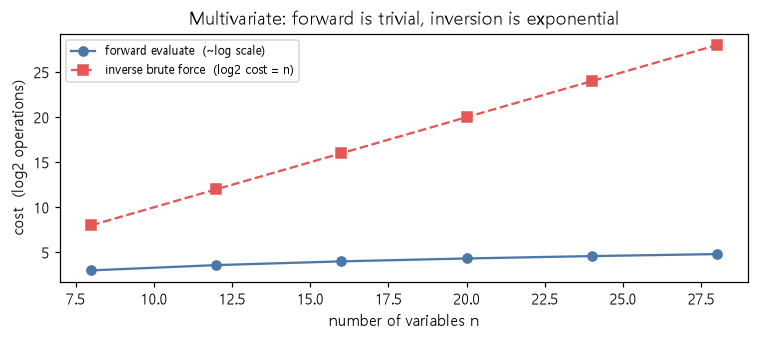

In [22]:
ns = [8, 12, 16, 20, 24, 28]
fwd_cost = [n for n in ns]                     # 대입: 대략 선형
inv_cost = [n for n in ns]                     # 완전탐색: 2^n (log2 = n)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ns, [np.log2(n) for n in ns], 'o-', label='forward evaluate  (~log scale)', color='#4C78A8')
ax.plot(ns, ns, 's--', label='inverse brute force  (log2 cost = n)', color='#E45756')
ax.set_xlabel('number of variables n'); ax.set_ylabel('cost  (log2 operations)')
ax.set_title('Multivariate: forward is trivial, inversion is exponential')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 3-1. 그래프 해석

가로축은 변수 개수 $n$, 세로축은 계산 비용을 **"2를 몇 번 곱해야 나오는 수인지"(log2)** 로 나타낸 값입니다.
파란 실선이 순방향(값 대입), 빨간 점선이 역방향(완전탐색)입니다.

빨간 점선은 곧게 올라가는 직선처럼 보이지만, 세로축이 "2를 곱한 횟수"라는 점이 함정입니다.
직선으로 한 칸 오를 때마다 실제 비용은 **2배씩** 커지므로, 실제 비용은 $2^n$ —
겉보기엔 완만해 보여도 사실은 **폭발적으로 커지고 있다**는 뜻입니다.

> **주의**: 이 그래프의 파란 선은 실제 측정 시간이 아니라 "순방향은 사실상 평평하다"는 것을 보여주는
> **개념선**입니다. 실제 측정값은 2장의 표를 참조하십시오 —
> 순방향 대입은 $n = 8 \sim 20$ 구간에서 약 **48~103 마이크로초**에 불과했습니다.

결국 "숫자를 식에 넣는 것은 순식간, 결과에서 거꾸로 찾는 것은 사실상 불가능"이라는
일방통행 성질이 그래프로 확인되며, 이 비대칭이 다변수 방식 서명의 재료가 됩니다.


### 3-2. 실무 적용성

- **측정**: 순방향 대입은 수 마이크로초, 역방향은 $2^n$ 완전탐색입니다.
  변수 수가 늘수록 격차가 폭발적으로 벌어집니다.
- **장점**: 계산이 단순한 식 대입뿐이라 **부채널 공격(기기의 전력 소모 패턴을 훔쳐보는
  전력분석 등)에 강하고**, 서명 검증이 빠릅니다. 용도는 **서명 전용**에 알맞습니다.
  스마트카드(교통카드·신용카드 IC칩 같은 소형 기기)류 서명 용도로 계속 연구되는 이유가 여기에 있습니다.
- **단점**: **키(공개해야 하는 레시피 계수들) 크기가 크고**, 일부 다변수 방식은 과거에
  레시피의 숨은 규칙성을 파고든 구조적 공격으로 깨진 이력이 있어 설계가 까다롭습니다.
  NIST(미국 표준기술연구소) 추가 서명 공모에서도 다변수 계열이 다수 평가 중입니다.

> **정리**: 다변수 방식은 "대입은 쉽고 역산은 불가능"한 성질로 만드는 서명입니다 —
> 부채널에 강하지만 키가 크고 설계가 까다롭습니다.


## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요. 어려운 수학 없이, 숫자만 바꿔 보면 됩니다.

1. **탐색 한계 늘리기**: 2장 검증 셀의 `for n in [8, 12, 16, 20]:` 에 `18` 을 추가하고,
   역산 조건 `if n <= 16:` 을 `if n <= 18:` 로 바꿔 실행해 보세요.
   $2^{18} = 262{,}144$ 회(약 26만 번) 시도에 시간이 얼마나 걸리는지,
   $n = 16$ 일 때와 비교해 몇 배인지 확인하세요.

2. **방정식이 부족하면?**: `mq_system(n, n, RNG)` 의 식 개수를 `mq_system(n, n // 2, RNG)` 로 줄이면
   방정식보다 변수가 많아집니다(단서보다 범인 후보가 많은 상황).
   완전탐색이 찾은 해 `xr` 이 원래 `x` 와 항상 같은지,
   답이 더 빨리(적은 `tries` 로) 발견되는지 관찰하고 이유를 생각해 보세요.

3. **측정 안정성**: `timeit(mq_eval, Qs, x, repeat=50)` 의 `repeat` 를 500으로 늘려
   `forward_us` 값이 얼마나 안정되는지 비교하세요. 100만분의 1초 단위처럼 아주 짧은 시간을 잴 때
   여러 번 반복해서 평균을 내는 이유를 생각해 보세요.

4. **비용 어림 계산**: 3장 시각화 셀의 `ns = [8, 12, 16, 20, 24, 28]` 을 `[8, 16, 24, 32, 40, 48]` 로
   바꿔 그리고, $n = 48$ 일 때 완전탐색 횟수 $2^{48}$ 이 몇 회인지 계산해 보세요.
   1초에 $10^6$ 회(100만 번)씩 시도할 수 있다면 몇 년이 걸릴까요?


## 요약

- **MQ 문제**(여러 변수가 얽힌 2차 방정식 여러 개를 동시에 푸는 문제): $y = P(x)$ 에서
  대입(순방향)은 순식간이지만, 결과만 보고 거꾸로 푸는 것(역방향)은
  **NP-난해**(현존 컴퓨터로 사실상 풀 수 없는 어려움 등급)다.
  요리 레시피대로 만들기는 쉬워도, 완성된 요리에서 레시피를 역추적하기는 어려운 것과 같다.
- 실측 결과, $n = 8 \sim 20$ 에서 순방향 대입은 약 **48~103μs**(100만분의 1초 단위)로
  완만히 증가한 반면, 역방향 시도 후보 수는 $256 \to 1{,}048{,}576$ 으로 폭발적으로 커졌다.
- 그래프에서 역방향 비용 선은 직선처럼 보이지만, 세로축이 "2를 곱한 횟수"이므로
  실제 비용은 $2^n$ — **폭발적 증가**를 뜻한다.
- 계산이 단순한 식 대입뿐이라 **부채널 공격(전력분석 등 곁가지 신호 훔쳐보기)에 강하며**,
  주 용도는 **전자서명**이다. 한국 KpqC 공모 최종 선정 서명 **AIMer** 도
  넓게 보면 일방향 함수 기반의 유사 계열이다.
- 단점은 **큰 키 크기**와 과거 구조적 공격 이력으로 인한 까다로운 설계이며,
  NIST 추가 서명 공모에서 다변수 계열이 다수 평가 중이다.

> 다변수 기반 암호는 "만들기는 쉽고 역추적은 불가능"이라는 가장 고전적인 일방통행 원리를
> 양자 시대에도 그대로 활용하는 계열입니다. 격자·해시 계열과 함께 PQC 서명의
> 다양성(암호 민첩성 — 한 방식이 깨져도 갈아탈 대안을 준비해 두는 전략)을 확보하는 역할을 합니다.
